In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings 
import logging
import seaborn as sns

working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_GSEA/Metabolic/Results"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs



# --- add this near the top (after imports) ---
COND_ORDER = [
    "Control",
    "Standard protocol",
    "Extended protocol",
    "Prematurely terminated",
    "PCMV",
    "Rejection",
]

COND_PALETTE = {
    "Control": "#EFE48E",
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
    "Prematurely terminated": "#C9B8D9",
    "PCMV": "#F0C096",
    "Rejection": "#E09E9E",
}


Running Scanpy 1.11.5, on 2026-01-22 10:32.


In [3]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/merging UMIs/CC_prepared_global_adata_raw_WITHOUT_lognorm.h5ad')

In [3]:
global_adata

AnnData object with n_obs × n_vars = 186947 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors'
    obsm: 'X_pca', 'X_umap'

In [9]:

# Extract relevant columns
mapping_df = global_adata.obs[['Sample_ID', 'Survival', 'Condition_subsets']].copy()

# Drop duplicates to only keep unique Sample_ID entries
unique_mapping = mapping_df.drop_duplicates().reset_index(drop=True)

# Show the table
print(unique_mapping)




   Sample_ID  Survival       Condition_subsets
0      PAV66        51       Standard protocol
1      PAV82        90       Standard protocol
2      PAV75        90       Standard protocol
3      PAV78        51               Rejection
4      PAV72       195       Extended protocol
5      PAV85       120       Extended protocol
6      PAV65        90       Standard protocol
7      PAV76        18               Rejection
8      PAV71       182       Extended protocol
9      PAV86       170               Rejection
10     PAV68        11                    PCMV
11     PAV84         0  Prematurely terminated
12     PAV73        15                    PCMV
13     PAV79        29               Rejection
14     PAV74        27                    PCMV
15     PAV83         1  Prematurely terminated
16     PAV67        90       Standard protocol
17     PAV69        90       Standard protocol
18     PAV80        90       Standard protocol
19         B         0                 Control
20         E 

In [3]:
# Step 2: Preprocess - Normalize and Log Transform
sc.pp.normalize_total(global_adata)
sc.pp.log1p(global_adata)

In [3]:
pathways = {
    # 🟢 Fatty Acid Metabolism (Normal & Adaptive)
    "Fatty_Acid_Metabolism": [
        "PPARA", "PPARGC1A", "CPT1A", "CPT1B", 
        "CPT2", "ACOX1", "ACADM", "ACADVL", 
        "FABP3", "SIRT1", "SIRT3", "PRKAA2",
        "HADH", "EHHADH", "SLC25A20", 

        'ACADL', 'ACADS', 'HADH', 'HADHB', 'HADHA'
    ],
    
    # 🟠 Ketone Metabolism (Alternative Energy Pathway)
    "Ketone_Metabolism": [
        "BDH1", "BDH2", "HMGCS2", "SLC16A6", 
        "OXCT1", "ACAT1",

         'SLC16A1', 'SLC16A7'
    ],
    
    # 🔴 Lactate Metabolism (Hypoxia Adaptation)
    "Lactate_Metabolism": [
       "LDHB", "SLC16A1", "SLC16A3", 
         "SIRT1", "HIF1A"
    ],

    # 🔵 Glycolysis & Glucose Oxidation (Shifted Metabolism)
    "Glycolysis_Glucose_Oxidation": [
        "SLC2A4", "HK1", "HK2",
        "PFKM", "PFKFB3", "PKM",
        "GPI", "ALDOA", "PDHA1", "PDK1",


        "PFKL", "LDHB", "ALDOB",  "KLF7",
        "ENO1", "ENO2", "ADH1C"
    ],
    
    # 🟣 Carbohydrate Metabolism (Overall Energy Balance)
    "Carbohydrate_Metabolism": [
        "G6PC", "PYGL", "PYGM", "GCK", 
        "PDK4", "SLC2A2", "SLC2A5", "FBP1", 
        "GPI", "ALDOB"
    ],

    # 🟢 Amino Acid Metabolism (Alternative Energy & Protein Turnover)
    "Amino_Acid_Metabolism": [
        "GLS", "GLUD1", "SLC1A5", "SLC38A1", 
        "ASNS", "BCAT2", "GPT2", "PHGDH",
        "PSAT1",

        "GOT1", "GOT2", "SLC7A11", "BCAT2", "BCAT1"
    ],

    # 🔵 Mitochondrial Function & TCA Cycle (Normal & Dysfunctional)
    "TCA_Cycle_Mitochondrial_Function": [
        "TFAM", "NDUFA9",   
        "ATP5F1B", "OGDH", "DLAT", "FH", 
        "SUCLG1", "CPT1A", "IDH3A"
    ],

    # 🛑 Metabolic Dysfunction (Pathological Energy Shifts)
    "Metabolic_Dysfunction": [
        "PDK4", "HIF1A", "LDHA", "SREBF1",
        "FABP4", "PRKAB1", "TXNRD1", "HMOX1",
        "UCP2", "UCP3", "G6PD"
    ],


}


# Combine all genes from all pathways into a single list
all_genes = [gene for genes in pathways.values() for gene in genes]

# Filter genes to only those present in the AnnData object
genes_in_data = [gene for gene in all_genes if gene in global_adata.var_names]

# Initialize a dictionary to store results
results = {
    'genes_above_threshold': [],
    'genes_below_threshold': []
}

genes_not_found = [gene for gene in all_genes if gene not in global_adata.var_names]
print(f"\nGenes NOT found in your dataset ({len(genes_not_found)}):")
print(genes_not_found)


# # Define the threshold
threshold = 0.0125

# Check each gene for minimum expression in at least one state
for gene in genes_in_data:
    # Group by 'cell_states' and calculate the mean expression for each state
    grouped_expression = global_adata[:, gene].to_df().groupby(global_adata.obs['cell_states']).mean()
    
    # Check if the maximum mean expression across states is above the threshold
    if grouped_expression.max().values[0] >= threshold:
        results['genes_above_threshold'].append(gene)
    else:
        results['genes_below_threshold'].append(gene)

# Print the results
print("Genes with minimum expression >= 0.0125 in at least one state:")
print(results['genes_above_threshold'])

print("\nGenes with minimum expression < 0.0125 in all states:")
print(results['genes_below_threshold'])

In [5]:
adata = global_adata.copy()

In [6]:
# Calculate gene set scores for each pathway
for pathway_name, gene_list in pathways.items():
    # Filter genes to only those present in the dataset
    genes_in_data = [gene for gene in gene_list if gene in adata.var_names]
    
    if len(genes_in_data) > 0:  # Only proceed if there are genes in the dataset
        sc.tl.score_genes(adata, gene_list=genes_in_data, score_name=pathway_name + "_score")
    else:
        print(f"No genes from {pathway_name} found in the dataset.")

# Save the AnnData object with the new scores
global_metabolic_gssa = adata.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_GSEA/Metabolic/files/global_metabolic_gssa.h5ad')

In [2]:
global_metabolic_gssa = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_GSEA/Metabolic/files/global_metabolic_gssa.h5ad')

In [10]:
global_metabolic_gssa

AnnData object with n_obs × n_vars = 186947 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets', 'Fatty_Acid_Metabolism_score', 'Ketone_Metabolism_score', 'Lactate_Metabolism_score', 'Glycolysis_Glucose_Oxidation_score', 'Carbohydrate_

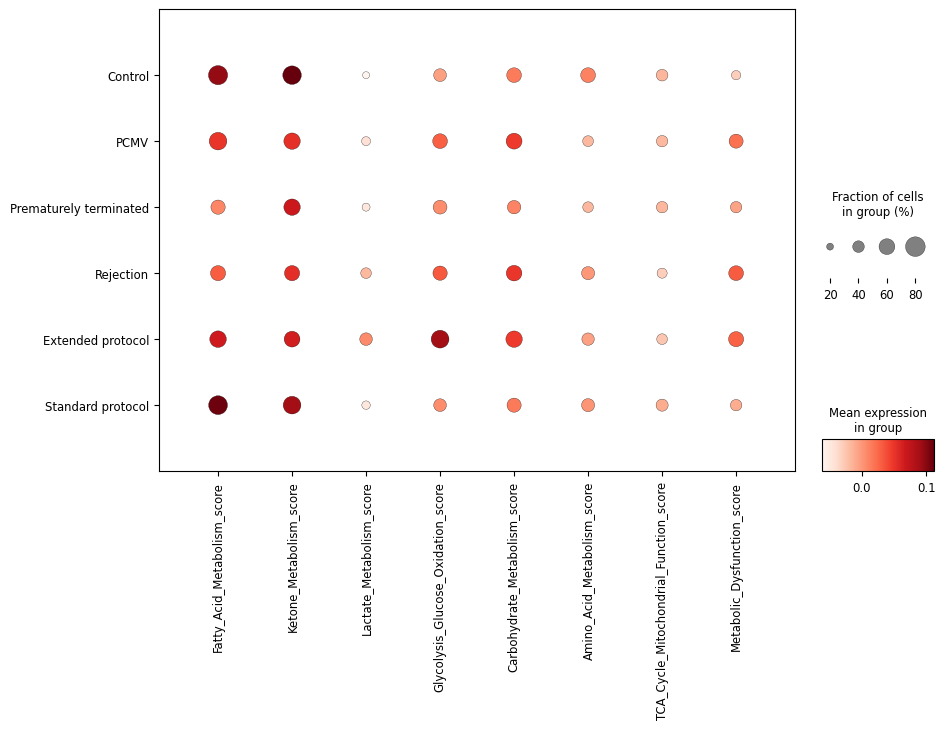

In [11]:
# Plot dot plot of gene set scores by cluster
sc.pl.dotplot(
    global_metabolic_gssa,
    var_names=[pathway_name + "_score" for pathway_name in pathways.keys()],
    groupby='Condition_subsets',
    # cmap='coolwarm',
    figsize=(10, 6)
)

In [12]:
adata = global_metabolic_gssa.copy()

           Fatty_Acid_Metabolism  Ketone_Metabolism  Lactate_Metabolism  Glycolysis_Glucose_Oxidation  Carbohydrate_Metabolism  Amino_Acid_Metabolism  TCA_Cycle_Mitochondrial_Function  Metabolic_Dysfunction
Sample_ID                                                                                                                                                                                                     
B                       0.100643           0.106610           -0.074448                     -0.011344                 0.039440               0.008441                         -0.022619              -0.006668
E                       0.086989           0.135032           -0.066606                     -0.006338                -0.036102              -0.005812                         -0.029822              -0.079477
F                       0.151627           0.140911           -0.090506                     -0.003116                 0.036019               0.031030                       

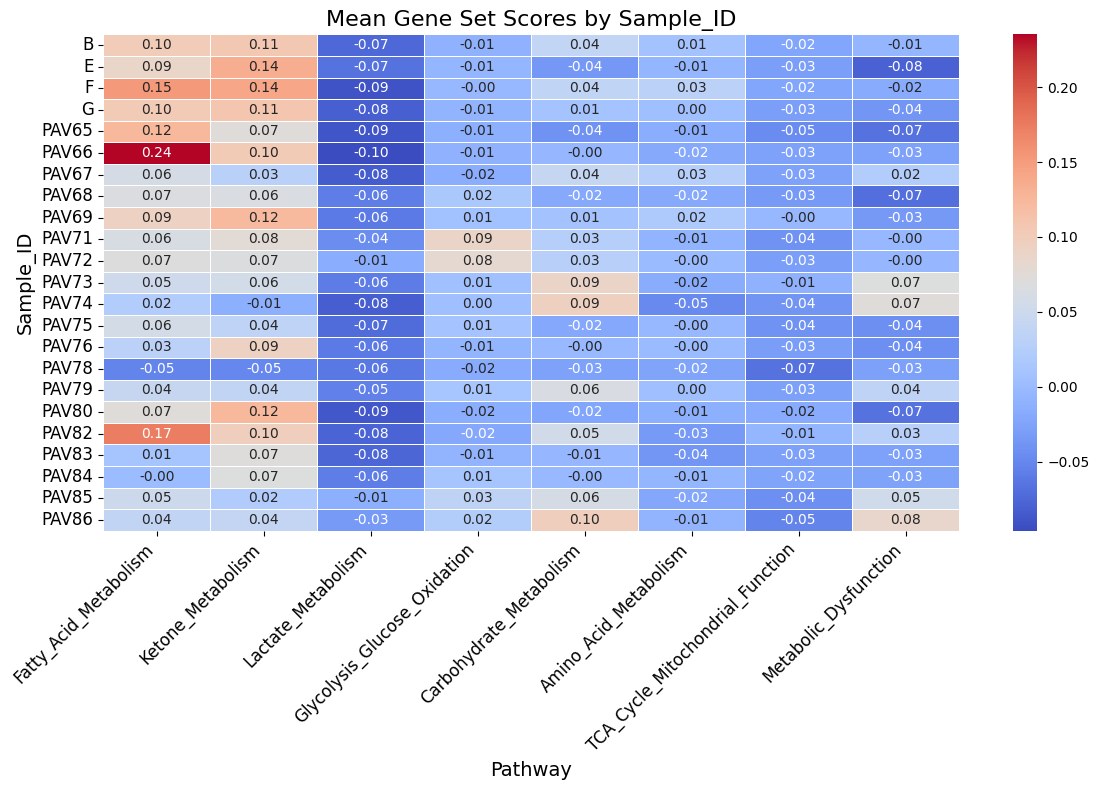

In [13]:
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Display the aggregated scores
print(sample_scores_df)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    sample_scores_df,
    cmap='coolwarm',  # Color map
    annot=True,  # Annotate cells with values
    fmt=".2f",  # Format annotations to 2 decimal places
    linewidths=0.5  # Add lines between cells
)

# Customize the plot
plt.title('Mean Gene Set Scores by Sample_ID', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Sample_ID', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

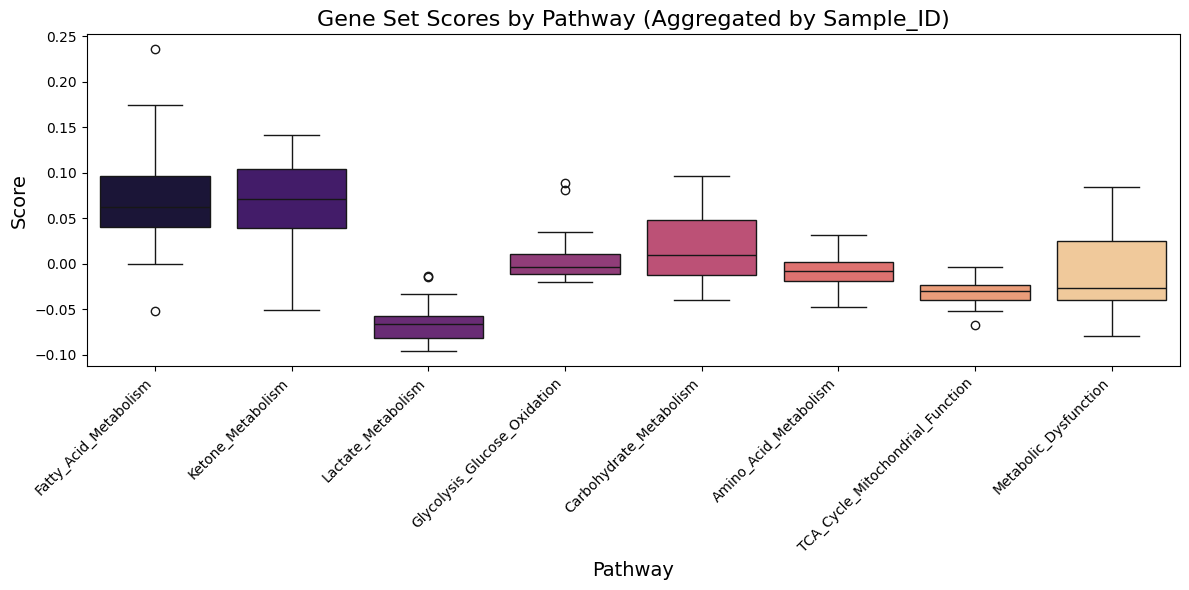

In [14]:
# It shows usean gene set scores across all samples for each pathway
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(var_name='Pathway', value_name='Score')

# Create a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores by Pathway (Aggregated by Sample_ID)', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

In [16]:
adata

AnnData object with n_obs × n_vars = 186947 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets', 'Apoptosis intrinsic_score', 'Apoptosis extrinsic_score', 'Oxidative stress_score', 'Necrosis_score', 'Pyroptosis_score', 'Ferroptosis (pr

   Condition_subsets                Pathway     Score
0            Control  Fatty_Acid_Metabolism  0.100643
1            Control  Fatty_Acid_Metabolism  0.086989
2            Control  Fatty_Acid_Metabolism  0.151627
3            Control  Fatty_Acid_Metabolism  0.102740
4  Standard protocol  Fatty_Acid_Metabolism  0.124155


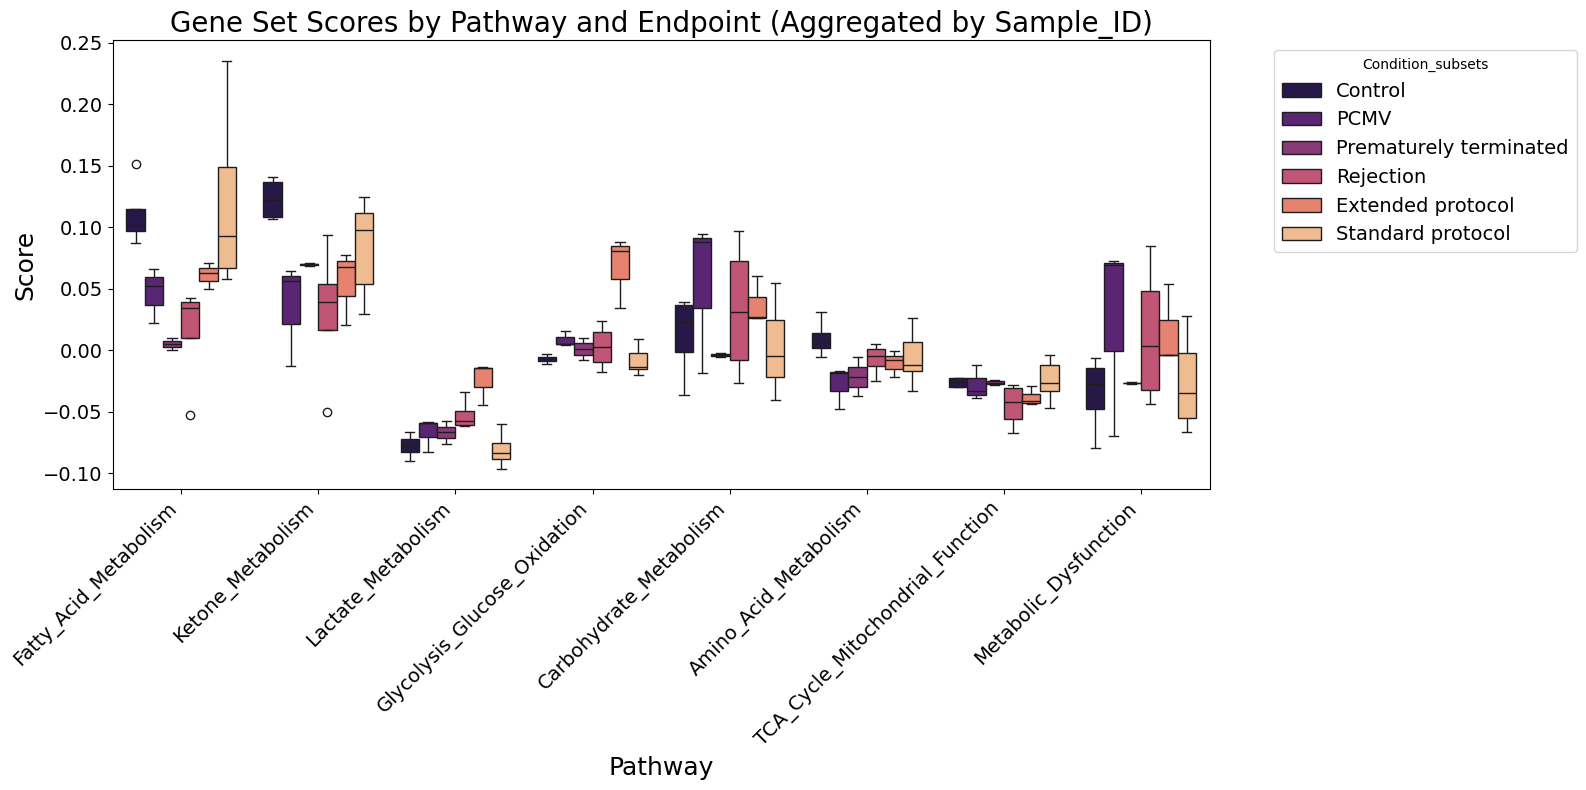

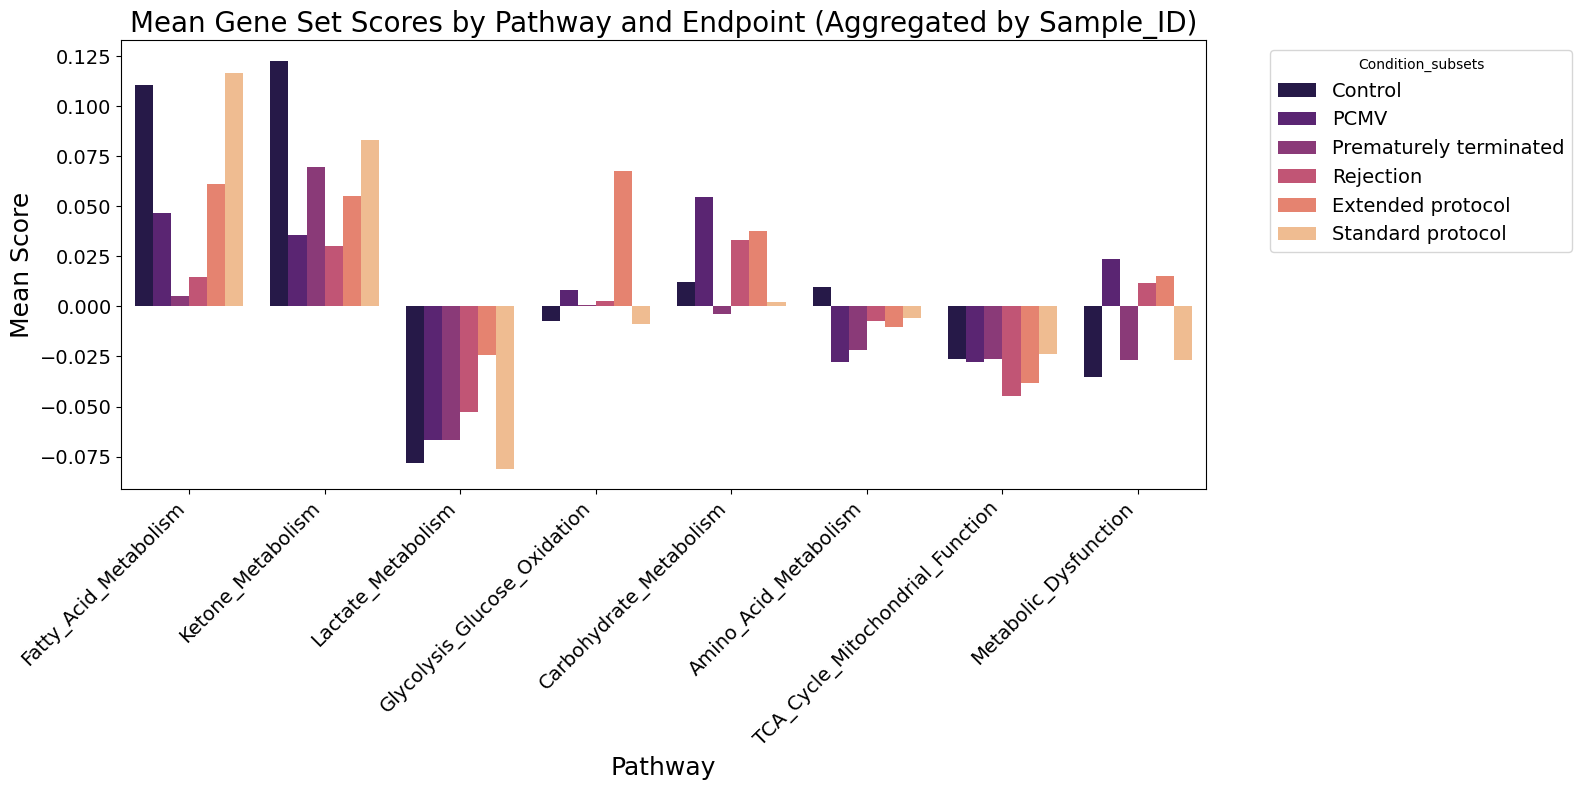

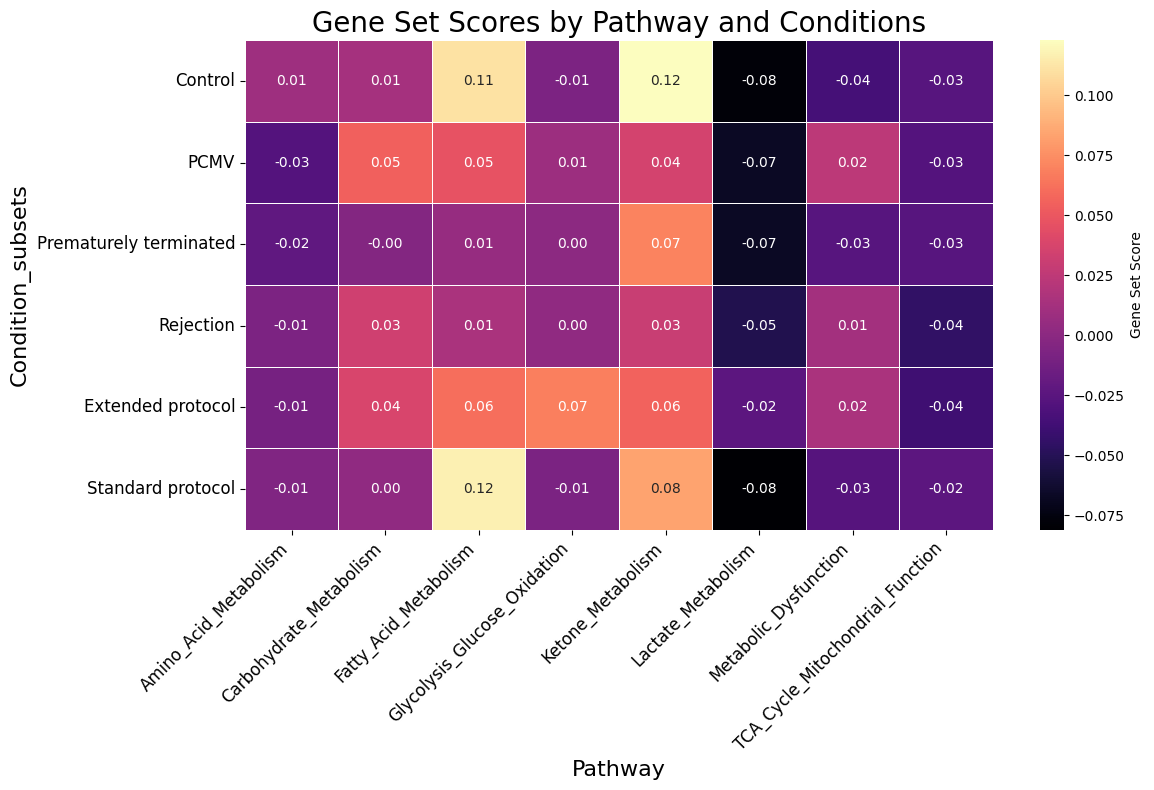

In [15]:
# Add new_endpoints information to the sample_scores_df DataFrame
sample_scores_df['Condition_subsets'] = adata.obs.groupby('Sample_ID')['Condition_subsets'].first()
# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(
    id_vars='Condition_subsets',  # Include new_endpoints information
    var_name='Pathway', 
    value_name='Score'
)

# Verify the melted DataFrame
print(sample_scores_melted.head())

import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',  # Color by new_endpoints
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores by Pathway and Endpoint (Aggregated by Sample_ID)', fontsize=20)
plt.xlabel('Pathway', fontsize=18)
plt.ylabel('Score', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=14)  # Increase y-axis tick font size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title='Condition_subsets')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()


# Create a bar plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',  # Color by new_endpoints
    palette='magma',
    estimator='mean',  # Use mean for aggregation
    ci=None  # Disable confidence intervals
)

# Customize the plot
plt.title('Mean Gene Set Scores by Pathway and Endpoint (Aggregated by Sample_ID)', fontsize=20)
plt.xlabel('Pathway', fontsize=18)
plt.ylabel('Mean Score', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=14)  # Increase y-axis tick font size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title='Condition_subsets')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the melted DataFrame to create a matrix for the heatmap
heatmap_data = sample_scores_melted.pivot_table(
    index='Condition_subsets',  # Rows: new_endpoints
    columns='Pathway',      # Columns: Pathways
    values='Score',         # Values: Gene set scores
    aggfunc='mean'          # Aggregate by mean (or median if preferred)
)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='magma',  # Color map
    annot=True,      # Annotate cells with values
    fmt=".2f",       # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    cbar_kws={'label': 'Gene Set Score'}  # Add a label to the color bar
)

# Customize the plot
plt.title('Gene Set Scores by Pathway and Conditions', fontsize=20)
plt.xlabel('Pathway', fontsize=16)
plt.ylabel('Condition_subsets', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

In [11]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_pathway_scoring_by_celltype(
    adata,
    pathways: dict,
    cell_type_col: str,
    sample_col: str = "Sample_ID",
    condition_col: str = "Condition_subsets",
    cond_order: list = None,
    cond_palette: dict = None,
    outdir: str = "./per_celltype_pathway_scores",
    aggregate_func: str = "median",  # or "mean"
    pathway_order: list = None,
    figure_dpi: int = 200,
):
    """
    For each cell type:
      - creates (and saves) boxplot, mean barplot, and heatmap of pathway scores
      - writes CSVs (per-sample wide, melted long, and per-condition mean heatmap matrix)
    Assumes per-cell pathway scores live in adata.obs as <pathway>_score.
    If missing, it computes them using sc.tl.score_genes.
    """

    # ---------- setup ----------
    Path(outdir).mkdir(parents=True, exist_ok=True)
    if cond_order is None:
        cond_order = sorted(adata.obs[condition_col].dropna().unique().tolist())
    if cond_palette is None:
        # build a palette deterministically if none provided
        cond_palette = dict(zip(cond_order, sns.color_palette(n_colors=len(cond_order))))
    if pathway_order is None:
        pathway_order = list(pathways.keys())

    # helper for safe file names
    def _safe(s: str) -> str:
        return "".join(c if c.isalnum() or c in "._-+" else "_" for c in str(s))

    # ---------- ensure scores exist ----------
    missing = []
    for pname, genes in pathways.items():
        score_col = f"{pname}_score"
        if score_col not in adata.obs.columns:
            missing.append(pname)
    if len(missing) > 0:
        import scanpy as sc
        # only compute using genes present
        for pname in missing:
            genes = [g for g in pathways[pname] if g in adata.var_names]
            if len(genes) == 0:
                print(f"[warn] No genes for pathway '{pname}' found in var_names; skipping score.")
                continue
            sc.tl.score_genes(adata, gene_list=genes, score_name=f"{pname}_score")

    # choose aggregator
    aggfunc = np.median if aggregate_func.lower() == "median" else np.mean

    # ---------- loop over cell types ----------
    cell_types = adata.obs[cell_type_col].dropna().unique().tolist()
    cell_types = sorted(cell_types, key=str)

    for ct in cell_types:
        ct_dir = Path(outdir) / _safe(ct)
        ct_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n=== Processing cell type: {ct} ===")

        ad_ct = adata[adata.obs[cell_type_col] == ct].copy()
        if ad_ct.n_obs == 0:
            print(f"[skip] No cells for '{ct}'.")
            continue

        # ---- build per-cell dataframe of scores (+ sample & condition) ----
        score_cols = []
        for pname in pathway_order:
            scname = f"{pname}_score"
            if scname in ad_ct.obs:
                score_cols.append(scname)
            else:
                print(f"[warn] Missing {scname} in '{ct}', will drop in plots.")
        if len(score_cols) == 0:
            print(f"[skip] No pathway scores present for '{ct}'.")
            continue

        df = ad_ct.obs[score_cols + [sample_col, condition_col]].copy()
        # rename columns to the plain pathway names
        col_map = {f"{p}_score": p for p in pathway_order if f"{p}_score" in df.columns}
        df = df.rename(columns=col_map)

        # ---- aggregate per Sample_ID (rows=samples) ----
        # use the chosen aggfunc across cells in the same sample (within this cell type)
        sample_scores_df = df.groupby(sample_col)[list(col_map.values())].agg(aggfunc)

        # attach the (first) condition per sample
        # (robust to mixed conditions per sample, but will take the first)
        sample_to_cond = (
            df[[sample_col, condition_col]]
            .dropna()
            .drop_duplicates()
            .groupby(sample_col)[condition_col]
            .first()
        )
        sample_scores_df[condition_col] = sample_to_cond.reindex(sample_scores_df.index)

        # enforce condition order & drop unseen levels for plotting
        present_conditions = [c for c in cond_order if c in sample_scores_df[condition_col].unique()]
        cond_palette_present = {c: cond_palette[c] for c in present_conditions if c in cond_palette}

        # ---- save wide per-sample CSV ----
        sample_csv_path = ct_dir / f"{_safe(ct)}__per_sample_{aggregate_func}.csv"
        sample_scores_df.to_csv(sample_csv_path, index=True)

        # ---- long/melted for seaborn ----
        melted = sample_scores_df.melt(
            id_vars=[condition_col],
            value_vars=[p for p in pathway_order if p in sample_scores_df.columns],
            var_name="Pathway",
            value_name="Score",
        )

        # keep only present conditions in the requested order
        melted = melted[melted[condition_col].isin(present_conditions)].copy()
        melted[condition_col] = pd.Categorical(melted[condition_col], categories=present_conditions, ordered=True)
        melted["Pathway"] = pd.Categorical(
            melted["Pathway"], categories=[p for p in pathway_order if p in melted["Pathway"].unique()], ordered=True
        )

        # ---- save melted CSV ----
        melted_csv_path = ct_dir / f"{_safe(ct)}__melted_{aggregate_func}.csv"
        melted.to_csv(melted_csv_path, index=False)

        # ---------- PLOTS ----------
        # 1) Boxplot by condition
        plt.figure(figsize=(18, 8))
        ax = sns.boxplot(
            data=melted,
            x="Pathway",
            y="Score",
            hue=condition_col,
            order=[p for p in pathway_order if p in melted["Pathway"].cat.categories],
            hue_order=present_conditions,
            palette=cond_palette_present,
        )
        plt.title(f"{ct} — Gene Set Scores by Pathway and Condition ({aggregate_func} per Sample_ID)", fontsize=18)
        plt.xlabel("Pathway", fontsize=14)
        plt.ylabel("Score", fontsize=14)
        plt.xticks(rotation=45, ha="right")
        plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title=condition_col)
        plt.tight_layout()
        boxplot_png = ct_dir / f"{_safe(ct)}__boxplot_{aggregate_func}.png"
        boxplot_pdf = ct_dir / f"{_safe(ct)}__boxplot_{aggregate_func}.pdf"
        plt.savefig(boxplot_png, dpi=figure_dpi)
        plt.savefig(boxplot_pdf)
        plt.close()

        # 2) Mean barplot by condition
        plt.figure(figsize=(18, 8))
        ax = sns.barplot(
            data=melted,
            x="Pathway",
            y="Score",
            hue=condition_col,
            order=[p for p in pathway_order if p in melted["Pathway"].cat.categories],
            hue_order=present_conditions,
            estimator=np.mean,
            ci=None,
            palette=cond_palette_present,
        )
        plt.title(f"{ct} — Mean Gene Set Scores by Pathway and Condition ({aggregate_func} per Sample_ID)", fontsize=18)
        plt.xlabel("Pathway", fontsize=14)
        plt.ylabel("Mean Score", fontsize=14)
        plt.xticks(rotation=45, ha="right")
        plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title=condition_col)
        plt.tight_layout()
        barplot_png = ct_dir / f"{_safe(ct)}__barplot_mean_{aggregate_func}.png"
        barplot_pdf = ct_dir / f"{_safe(ct)}__barplot_mean_{aggregate_func}.pdf"
        plt.savefig(barplot_png, dpi=figure_dpi)
        plt.savefig(barplot_pdf)
        plt.close()

        # 3) Heatmap (mean over samples within each condition)
        heatmap_df = (
            melted
            .groupby([condition_col, "Pathway"])["Score"]
            .mean()
            .reset_index()
            .pivot(index=condition_col, columns="Pathway", values="Score")
            .reindex(index=present_conditions)
        )
        # ensure column order
        heatmap_df = heatmap_df.reindex(columns=[p for p in pathway_order if p in heatmap_df.columns])

        # save heatmap matrix as CSV
        heatmap_csv = ct_dir / f"{_safe(ct)}__heatmap_matrix_mean_{aggregate_func}.csv"
        heatmap_df.to_csv(heatmap_csv)

        plt.figure(figsize=(12, 8))
        sns.heatmap(
            heatmap_df,
            cmap="magma",
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={"label": "Gene Set Score"},
        )
        plt.title(f"{ct} — Mean Gene Set Scores by Pathway × Condition", fontsize=18)
        plt.xlabel("Pathway", fontsize=14)
        plt.ylabel(condition_col, fontsize=14)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        heatmap_png = ct_dir / f"{_safe(ct)}__heatmap_mean_{aggregate_func}.png"
        heatmap_pdf = ct_dir / f"{_safe(ct)}__heatmap_mean_{aggregate_func}.pdf"
        plt.savefig(heatmap_png, dpi=figure_dpi)
        plt.savefig(heatmap_pdf)
        plt.close()

        print(f"Saved for '{ct}':")
        print(f"  CSV (per-sample): {sample_csv_path}")
        print(f"  CSV (melted):     {melted_csv_path}")
        print(f"  CSV (heatmap):    {heatmap_csv}")
        print(f"  Plots:            {boxplot_png}, {barplot_png}, {heatmap_png}")

# ---------------- How to run ----------------
# Choose the column that holds your cell types:
# e.g., "cell_type", "manual_celltype_annotation_Group1", "EC_subtype_annotation", etc.
cell_type_column_name = "cell_type"  # <-- CHANGE THIS to your column

run_pathway_scoring_by_celltype(
    adata=adata,
    pathways=pathways,
    cell_type_col=cell_type_column_name,
    sample_col="Sample_ID",
    condition_col="Condition_subsets",
    cond_order=COND_ORDER,
    cond_palette=COND_PALETTE,
    outdir="./Metabolic_GeneSetScores_byCellType",
    aggregate_func="median",          # or "mean"
    pathway_order=list(pathways.keys()),
    figure_dpi=300,
)



=== Processing cell type: CM ===
Saved for 'CM':
  CSV (per-sample): Metabolic_GeneSetScores_byCellType/CM/CM__per_sample_median.csv
  CSV (melted):     Metabolic_GeneSetScores_byCellType/CM/CM__melted_median.csv
  CSV (heatmap):    Metabolic_GeneSetScores_byCellType/CM/CM__heatmap_matrix_mean_median.csv
  Plots:            Metabolic_GeneSetScores_byCellType/CM/CM__boxplot_median.png, Metabolic_GeneSetScores_byCellType/CM/CM__barplot_mean_median.png, Metabolic_GeneSetScores_byCellType/CM/CM__heatmap_mean_median.png

=== Processing cell type: Endocardial/lymphatic EC ===
Saved for 'Endocardial/lymphatic EC':
  CSV (per-sample): Metabolic_GeneSetScores_byCellType/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC__per_sample_median.csv
  CSV (melted):     Metabolic_GeneSetScores_byCellType/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC__melted_median.csv
  CSV (heatmap):    Metabolic_GeneSetScores_byCellType/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC__heatmap_matrix_mean_median

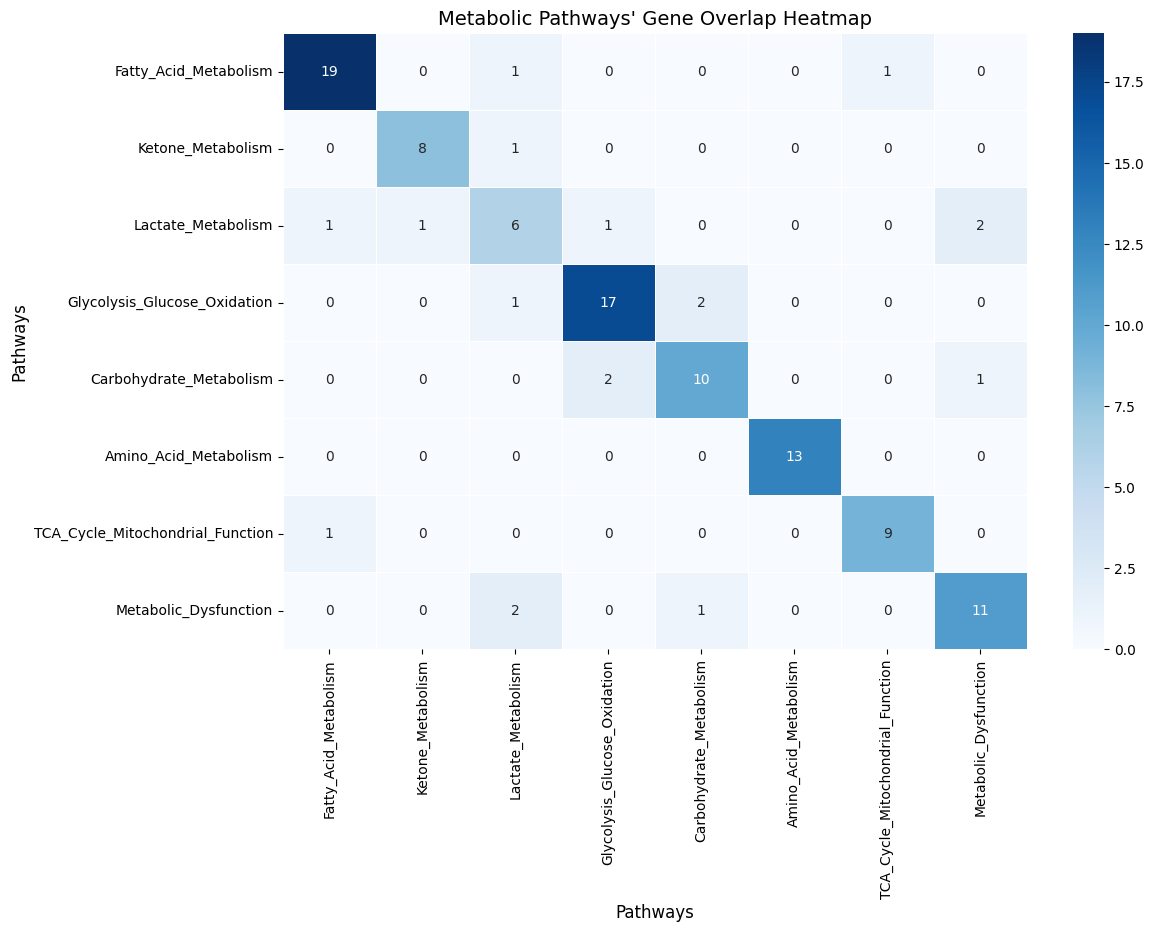

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure pathways dictionary is correctly defined
pathways = {
    # 🟢 Fatty Acid Metabolism (Normal & Adaptive)
    "Fatty_Acid_Metabolism": [
        "PPARA", "PPARGC1A", "CPT1A", "CPT1B", 
        "CPT2", "ACOX1", "ACADM", "ACADVL", 
        "FABP3", "SIRT1", "SIRT3", "PRKAA2",
        "HADH", "EHHADH", "SLC25A20", 

        'ACADL', 'ACADS', 'HADH', 'HADHB', 'HADHA'
    ],
    
    # 🟠 Ketone Metabolism (Alternative Energy Pathway)
    "Ketone_Metabolism": [
        "BDH1", "BDH2", "HMGCS2", "SLC16A6", 
        "OXCT1", "ACAT1",

         'SLC16A1', 'SLC16A7'
    ],
    
    # 🔴 Lactate Metabolism (Hypoxia Adaptation)
    "Lactate_Metabolism": [
        "LDHA", "LDHB", "SLC16A1", "SLC16A3", 
         "SIRT1", "HIF1A"
    ],

    # 🔵 Glycolysis & Glucose Oxidation (Shifted Metabolism)
    "Glycolysis_Glucose_Oxidation": [
        "SLC2A4", "HK1", "HK2",
        "PFKM", "PFKFB3", "PKM",
        "GPI", "ALDOA", "PDHA1", "PDK1",


        "PFKL", "LDHB", "ALDOB",  "KLF7",
        "ENO1", "ENO2", "ADH1C"
    ],
    
    # 🟣 Carbohydrate Metabolism (Overall Energy Balance)
    "Carbohydrate_Metabolism": [
        "G6PC", "PYGL", "PYGM", "GCK", 
        "PDK4", "SLC2A2", "SLC2A5", "FBP1", 
        "GPI", "ALDOB"
    ],

    # 🟢 Amino Acid Metabolism (Alternative Energy & Protein Turnover)
    "Amino_Acid_Metabolism": [
        "GLS", "GLUD1", "SLC1A5", "SLC38A1", 
        "ASNS", "BCAT2", "GPT2", "PHGDH",
        "PSAT1",

        "GOT1", "GOT2", "SLC7A11", "BCAT2", "BCAT1"
    ],

    # 🔵 Mitochondrial Function & TCA Cycle (Normal & Dysfunctional)
    "TCA_Cycle_Mitochondrial_Function": [
        "TFAM", "NDUFA9",   
        "ATP5F1B", "OGDH", "DLAT", "FH", 
        "SUCLG1", "CPT1A", "IDH3A"
    ],

    # 🛑 Metabolic Dysfunction (Pathological Energy Shifts)
    "Metabolic_Dysfunction": [
        "PDK4", "HIF1A", "LDHA", "SREBF1",
        "FABP4", "PRKAB1", "TXNRD1", "HMOX1",
        "UCP2", "UCP3", "G6PD"
    ]}

# Compute the overlap matrix
pathway_names = list(pathways.keys())
num_pathways = len(pathway_names)

# Initialize the overlap matrix
overlap_matrix = np.zeros((num_pathways, num_pathways))

# Compute gene overlap between pathways
for i, pathway1 in enumerate(pathway_names):
    for j, pathway2 in enumerate(pathway_names):
        if i <= j:  # Avoid redundant calculations
            genes1 = set(pathways[pathway1])
            genes2 = set(pathways[pathway2])
            shared_genes = genes1.intersection(genes2)
            overlap_matrix[i, j] = len(shared_genes)
            overlap_matrix[j, i] = len(shared_genes)  # Mirror values

# Convert to DataFrame for Seaborn
overlap_df = pd.DataFrame(overlap_matrix, index=pathway_names, columns=pathway_names)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(overlap_df, annot=True, cmap="Blues", fmt=".0f", linewidths=0.5)
plt.title("Metabolic Pathways' Gene Overlap Heatmap", fontsize=14)
plt.xlabel("Pathways", fontsize=12)
plt.ylabel("Pathways", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


Heatmap saved to: Condition_subsets_Metabolic_Correlation_Heatmap.pdf with 300 dpi.


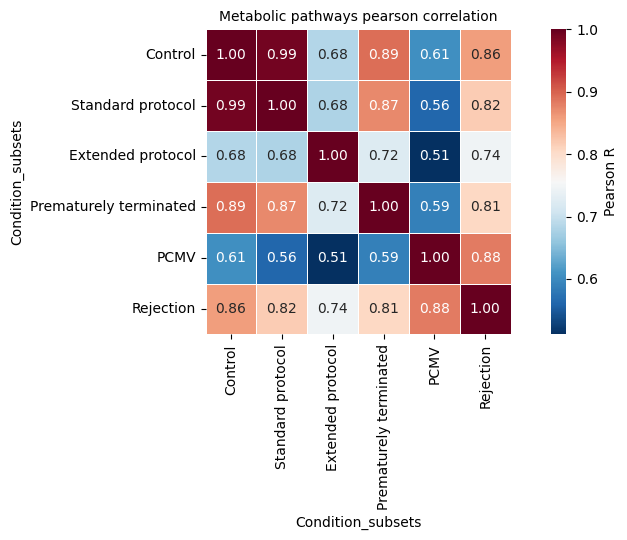

In [4]:
# --- Pearson correlation of Condition_subsets over metabolic profile ---

adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_GSEA/Metabolic/files/global_metabolic_gssa.h5ad')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Collect pathway score columns from .obs
pathway_score_cols = [f"{p}_score" for p in pathways.keys()]
pathway_score_cols = [c for c in pathway_score_cols if c in adata.obs.columns]

if len(pathway_score_cols) == 0:
    raise ValueError("No pathway score columns found in adata.obs. Expected *_score columns from your `pathways` dict.")

# 2) Build a per-cell dataframe with Sample_ID and Condition_subsets
df_cells = adata.obs[pathway_score_cols + ['Sample_ID', 'Condition_subsets']].copy()

# 3) Aggregate to per-sample (median across cells per sample)
df_sample = (
    df_cells
    .groupby('Sample_ID', as_index=True)[pathway_score_cols]
    .median()
)

# attach the Condition_subsets per-sample
sample_to_condition = (
    adata.obs[['Sample_ID', 'Condition_subsets']]
    .drop_duplicates()
    .set_index('Sample_ID')['Condition_subsets']
)
df_sample['Condition_subsets'] = sample_to_condition.loc[df_sample.index].values

# 4) Aggregate to per-condition profile (median of samples within each condition)
df_condition = (
    df_sample
    .groupby('Condition_subsets', as_index=True)[pathway_score_cols]
    .median()
)

# 5) (Optional) Reorder conditions by your predefined order if present
if 'COND_ORDER' in globals() and isinstance(COND_ORDER, (list, tuple)):
    order = [c for c in COND_ORDER if c in df_condition.index]
    # Append any conditions not in COND_ORDER at the end to avoid dropping them
    order += [c for c in df_condition.index if c not in order]
    df_condition = df_condition.loc[order]

# 6) Compute Pearson correlation between conditions (over pathways)
# df_condition: rows = Condition_subsets, columns = pathways
corr_mat = df_condition.T.corr(method='pearson')  # conditions x conditions

# 7) Plot heatmap
plt.figure(figsize=(9, 5.5))
sns.heatmap(
    corr_mat,
    # vmin=0, vmax=1,
    cmap='RdBu_r',
    annot=True, fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson R'}
)
plt.title('Metabolic pathways pearson correlation', fontsize=10)

plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()

# --- MODIFICATION START ---

# Define the filename
output_filename = 'Condition_subsets_Metabolic_Correlation_Heatmap.pdf'

# Save the figure as a PDF with 300 dpi
# For vector formats like PDF, the DPI setting primarily controls the resolution
# of any rasterized elements (like shadows or transparency), but it's good practice.
# We also ensure the editable text setting from your initial setup is honored.
plt.savefig(
    output_filename, 
    format='pdf', 
    dpi=300, 
    bbox_inches='tight' # Ensures no labels are clipped
)

print(f"Heatmap saved to: {output_filename} with 300 dpi.")

# --- MODIFICATION END ---

plt.show()

Output directory ensured: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/
✅ Saved median metabolic scores per condition (Input Data) to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/Aggregated_Condition_Metabolic_Profiles.csv
✅ Saved Pearson correlation matrix (Output Data) to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/Condition_Metabolic_Pearson_Correlation_Matrix.csv
Heatmap saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/Condition_subsets_Metabolic_Correlation_Heatmap.pdf with 300 dpi.


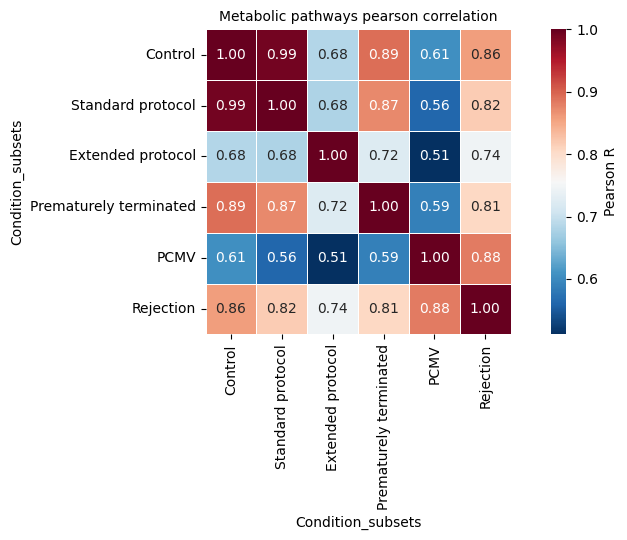

In [5]:
# --- Pearson correlation of Condition_subsets over metabolic profile ---

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os # Import os for directory handling

# --- CONFIGURATION ---
# Define the output directory (as per your request)
OUTPUT_DIR = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory ensured: {OUTPUT_DIR}")

# NOTE: The variables 'adata', 'pathways', and 'COND_ORDER' must be defined
# and loaded globally in your environment for this script to run.
# Assuming 'adata', 'pathways', and 'COND_ORDER' are available.
# ---------------------

# 1) Collect pathway score columns from .obs
# Using a placeholder 'pathways' dict for demonstration if not globally available
# Example: pathways = {'Metabolic_Pathway_A': [], 'Metabolic_Pathway_B': []}
try:
    pathway_score_cols = [f"{p}_score" for p in pathways.keys()]
except NameError:
    # This block handles the case if 'pathways' is undefined for testing purposes
    print("Warning: 'pathways' not defined. Assuming specific score columns for placeholder.")
    pathway_score_cols = ['pathway_A_score', 'pathway_B_score', 'pathway_C_score']


# Filter for actual columns present in adata.obs
if 'adata' in globals():
    pathway_score_cols = [c for c in pathway_score_cols if c in adata.obs.columns]
else:
    # Placeholder path for code completion if adata is not loaded
    print("Error: 'adata' (AnnData object) is not defined. Cannot proceed with aggregation.")
    exit()


if len(pathway_score_cols) == 0:
    raise ValueError("No pathway score columns found in adata.obs. Expected *_score columns from your `pathways` dict.")

# 2) Build a per-cell dataframe with Sample_ID and Condition_subsets
df_cells = adata.obs[pathway_score_cols + ['Sample_ID', 'Condition_subsets']].copy()

# 3) Aggregate to per-sample (median across cells per sample)
df_sample = (
    df_cells
    .groupby('Sample_ID', as_index=True)[pathway_score_cols]
    .median()
)

# attach the Condition_subsets per-sample
sample_to_condition = (
    adata.obs[['Sample_ID', 'Condition_subsets']]
    .drop_duplicates()
    .set_index('Sample_ID')['Condition_subsets']
)
df_sample['Condition_subsets'] = sample_to_condition.loc[df_sample.index].values

# 4) Aggregate to per-condition profile (median of samples within each condition)
df_condition = (
    df_sample
    .groupby('Condition_subsets', as_index=True)[pathway_score_cols]
    .median()
)

# 5) (Optional) Reorder conditions by your predefined order if present
if 'COND_ORDER' in globals() and isinstance(COND_ORDER, (list, tuple)):
    order = [c for c in COND_ORDER if c in df_condition.index]
    # Append any conditions not in COND_ORDER at the end to avoid dropping them
    order += [c for c in df_condition.index if c not in order]
    df_condition = df_condition.loc[order]


# --- NEW: Save the Aggregated Metabolic Profiles (Input Data) ---
csv_input_filename = 'Aggregated_Condition_Metabolic_Profiles.csv'
csv_input_path = os.path.join(OUTPUT_DIR, csv_input_filename)
# Save the index (Condition_subsets) as a column for clarity in the CSV
df_condition.reset_index().to_csv(csv_input_path, index=False)
print(f"✅ Saved median metabolic scores per condition (Input Data) to: {csv_input_path}")
# -----------------------------------------------------------------


# 6) Compute Pearson correlation between conditions (over pathways)
# df_condition: rows = Condition_subsets, columns = pathways
corr_mat = df_condition.T.corr(method='pearson')  # conditions x conditions


# --- NEW: Save the Pearson Correlation Matrix (Output Data) ---
csv_corr_filename = 'Condition_Metabolic_Pearson_Correlation_Matrix.csv'
csv_corr_path = os.path.join(OUTPUT_DIR, csv_corr_filename)
# Save the matrix, keeping the condition names as the index/column names
corr_mat.to_csv(csv_corr_path, index=True)
print(f"✅ Saved Pearson correlation matrix (Output Data) to: {csv_corr_path}")
# ---------------------------------------------------------------


# 7) Plot heatmap
plt.figure(figsize=(9, 5.5))
sns.heatmap(
    corr_mat,
    # vmin=0, vmax=1,
    cmap='RdBu_r',
    annot=True, fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson R'}
)
plt.title('Metabolic pathways pearson correlation', fontsize=10)

plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()

# Define the filename and path for the PDF
pdf_filename = 'Condition_subsets_Metabolic_Correlation_Heatmap.pdf'
pdf_output_path = os.path.join(OUTPUT_DIR, pdf_filename)

# Save the figure as a PDF with 300 dpi
plt.savefig(
    pdf_output_path,
    format='pdf',
    dpi=300,
    bbox_inches='tight' # Ensures no labels are clipped
)

print(f"Heatmap saved to: {pdf_output_path} with 300 dpi.")

plt.show()